In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN 
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# Unsupervised Modeling Notes

In [ ]:
df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
#dropping features w little correlation and categorical features
df_model = df.drop(['sjit', 'sloss', 'trans_depth', 'dinpkt', 'smean', 
                        'is_ftp_login', 'ct_ftp_cmd', 'proto', 'service', 'state', 'attack_cat',
                        'label', 'id'], axis=1)
#scaler to make sure all features are measured the same in the models
std_scaler = StandardScaler()
df_scaled = std_scaler.fit_transform(df_model)
#converting it back into a dataframe 
df_scaled = pd.DataFrame(df_scaled, columns= df_model.columns)

df_scaled
df_scaled.describe()

## DBSCAN
DBSCAN is a density-based clustering method that clusters points within epsilon range with a min number of neighbors, isolates any outliers (anamolies in this case)
- Dropped multiple features, including categorical ones, to create the model for DBSCAN 
- Scaled all the features left so that they are on the same measurements 
- Reduced the sample size for DBSCAN to 10,000 because it originally had 175,341 rows which would take too long for the model 
- DBSCAN found 1549 outliers out of 10,000 (15.5% anomaly rate)
  - Does not match up with the percentage of attacks vs normal traffic in original data (had 68% attack rate)
  - Could be missing attacks or lots of attacks look similar to normal traffic 
- Reduced the dimensionality of the data to 2D with PCA so that it could be better visualized 
  - Visualized the data with a scatter plot 
  - In plot DBSCAN struggled to differentiate attacks from normal traffic likely due to the high dimensionality of the data 
- DBSCAN was not well suited for a high dimensional dataset like this one

<Axes: >

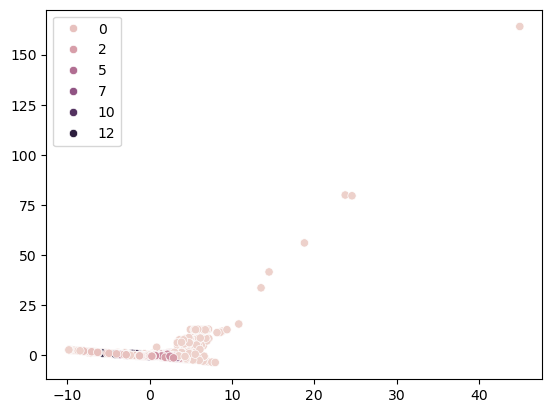

In [ ]:
#DBSCAN
#sampling 10000 rows from the dataset 
df_sample_dbsc = df_scaled.sample(n=10000, random_state=42)

#min number of samples near a point to classify it as a core object (1 more than num of features)
min_samples = 33
#distance that point has to be from the core object to be apart of its cluster
eps = np.sqrt(2)
#fitting the model so it can find clusters and outliers             
db = DBSCAN(eps=eps, min_samples=min_samples).fit(df_sample_dbsc)
#labeling the points and how many were clustered in a specific group or were outliers
db.labels_
#counting the number of points in each cluster 
#wrapping it in a pandas series because db.labels_ is a numpy array so value_counts cant be performed on it solely
pd.Series(db.labels_).value_counts()

#reducing the dimension of my features (32) into 2D with PCA for visualization 
pca = PCA(n_components = 2).fit_transform(df_sample_dbsc)
#creating a scatterplot of the points
sns.scatterplot(x = pca[:, 0], y = pca[:, 1], hue = db.labels_)

## ISOLATION FOREST
Isolation Forest is a method that specifically isolates outliers or anamolies from a large dataset by partitioning data using decision trees
- Isolation forest was able to take the entire data set as a sample size (as opposed to DBSCAN)
- Set the contamination to .50 because that’s as high as sklearn allows 
  - 1(normal): 87,675
  - -1(anomalies): 87,666
- Scatterplot to visualize results 
  - Clear distinction in color between 1(purple) and -1(light pink)
  - Normal traffic was lower in the chart and remained close in proximity
  - Anomalies were also lower in the chart but gradually made their way up the Y axis in a diagonal pattern
    - Some spots were isolated near the top corner 
- May indicate that Isolation Forest was able to distinguish between normal traffic and anomalies more than DBSCAN (likely due to Isolation Forest working better with high dimensional data and large datasets)



<Axes: >

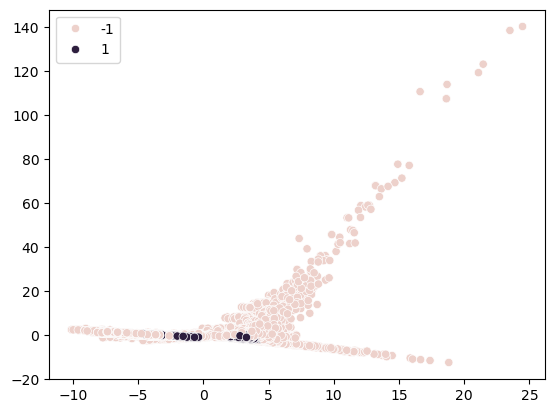

In [14]:
#isolation forest 
iso_forest = IsolationForest(n_estimators = 100, contamination = 0.5, max_samples = 175341)
#fitting and predicting the data to receieve labels 
iso_predictions = iso_forest.fit(df_scaled).predict(df_scaled)
iso_predictions

#showing count of 1's and -1's 
pd.Series(iso_predictions).value_counts()

#reducing dimension of features with PCA
pca_iso = PCA(n_components = 2).fit_transform(df_scaled)
#plotting the results with a scatterplot 
sns.scatterplot(x=pca_iso[:,0], y=pca_iso[:,1], hue=iso_predictions)